<a href="https://colab.research.google.com/github/AcSsalazar/the-color-of-emotions/blob/main/Notebooks/3.2-feature-extraction-with-pytorch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Generando tensores mediante el uso de Pytoch - Torchaudio

En este notebook vamos a realizar un proceso similar a lo estudiado anteriormente, con la diferencia de que durante este proceso **no** se hara uso de la libreria `Librosa`, sino que haremos la extraccion de las carateristicas acusticas, mediante la libreria `Pytorch`, la cual usa GPU este tipo de runtime sirve para optmizar tiempo de procesamiento.

Ademas, vamos a extraer caracteristicas diferentes para nuestros tres canales pertenecientes a los tensores, en lugar de usar MFCC, y sus dos derivadas (delta, delta-delta), vamos a usar espectrograma de mel, por su buen rendimiento en pruebas vistas antes con los archivos PNG, su delta de orden uno yel espectrogrma cochlear.

In [29]:
# Imports
#-----------------------------------------------
import os
import torch
import random
import tqdm
import pandas as pd
import matplotlib.pyplot as plt
import torchaudio
import torch.nn.functional as F
import torchaudio.transforms as T
import kagglehub
import shutil
#------------------------------------------------
from torch.utils.data import Dataset

In [3]:
# Descargarmos directamente desde Kaggle
path = kagglehub.dataset_download("uwrfkaggler/ravdess-emotional-speech-audio")
path_crema = kagglehub.dataset_download("ejlok1/cremad")

Using Colab cache for faster access to the 'ravdess-emotional-speech-audio' dataset.


100%|██████████| 451M/451M [00:12<00:00, 38.9MB/s]

Extracting files...


In [4]:
# Variables de configuración y rutas
#--------------------------------------------------------------------------
FAST_ROOT_DIR = '/content/datasets'
os.makedirs(FAST_ROOT_DIR, exist_ok=True)
# Config
SAMPLE_RATE = 16000 # Limitado por CREMA
MIN_DURATION = 0.5
MAX_DURATION = 3
N_MELS = 60
TARGET_SAMPLES = (SAMPLE_RATE * MAX_DURATION )
HOP_LENGTH = 512
# Cálculo matemático del ancho del tensor (Frames)
TARGET_FRAMES = int((SAMPLE_RATE * MAX_DURATION) / HOP_LENGTH) + 1 # ~94 frames
PAD_MODE = "constant" # Para padding de audios cortos
# Rutas Faster
#-------------------------------------------------------------------------
OUT_DIR_PY_TENSORS = '/content/split_pytorch_tensors'
os.makedirs(OUT_DIR_PY_TENSORS, exist_ok=True)

In [5]:
# Copiamos a local(session) para mayor velocidad en el procesamiento (SSD)
!cp -r {path}/* {FAST_ROOT_DIR}
!cp -r {path_crema}/* {FAST_ROOT_DIR}

In [6]:
# Eliminamos los archivos duplicados dentro de ravdess
from genericpath import isdir
target_dir = os.path.join(FAST_ROOT_DIR, "audio_speech_actors_01-24")

if os.path.isdir(target_dir):
  shutil.rmtree(target_dir)
  print("Directorio eliminado")
else:
  ("Directorio no encontrado")

Directorio eliminado


In [7]:
def get_actor_and_emotion(filename):
  """Extrae Actor ID y Emoción basándose en la nomenclatura estricta de RAVDESS/CREMA-D"""
  if filename.startswith('03'): # Nomenclatura Ravdess (ej. 03-02-XX-01-01-02.wav)
    parts = filename.split('-')
    if len(parts) != 7: return 'unknown'
    actor_id = f"ravdess_{parts[-1].replace('.wav', '')}" # En Python, los índices negativos cuentan desde el final hacia atrás
    rav_map = {1:'neutral', 2:'neutral', 3:'happy', 4:'sad', 5:'angry', 6:'fearful', 7:'disgust', 8:'surprised'}
    emotion = rav_map.get(int(parts[2]), 'unknown')
    return actor_id, emotion

  else: # Nomenclatura CREMA-D (ej. 1001_DFA_ANG_XX.wav)
      parts = filename.split('_')
      if len(parts) < 3: return None, 'unknown'
      actor_id = f"crema_{parts[0]}"
      crema_map = {'NEU':'neutral', 'HAP':'happy', 'SAD':'sad', 'ANG':'angry', 'FEA':'fearful', 'DIS':'disgust'}
      emotion = crema_map.get(parts[2].upper(), 'unknown')
      return actor_id, emotion


# 1. Mapeo de archivos físicos (aqui se mapearian las copias si no las eliminamos)
all_files = [os.path.join(root, f) for root, dirs, files in os.walk(FAST_ROOT_DIR) for f in files if f.endswith('.wav')]
actor_to_files = {}

for f in all_files:
    actor, emo = get_actor_and_emotion(os.path.basename(f))
    if emo == 'unknown': continue
    if actor not in actor_to_files: actor_to_files[actor] = []
    actor_to_files[actor].append(f)

# 2. Partición estocástica de Actores (80% Train, 10% Val, 10% Test)
unique_actors = __builtins__.list(actor_to_files.keys())
random.seed(42) # Semilla inmutable para consistencia entre ejecuciones
random.shuffle(unique_actors)

train_split = int(0.8 * len(unique_actors))
val_split = int(0.9 * len(unique_actors))

actor_splits = {}
for a in unique_actors[:train_split]: actor_splits[a] = 'train'
for a in unique_actors[train_split:val_split]: actor_splits[a] = 'val'
for a in unique_actors[val_split:]: actor_splits[a] = 'test'

print(f"Total Actores: {len(unique_actors)} | Train: {train_split} | Val: {val_split - train_split} | Test: {len(unique_actors) - val_split}")


Total Actores: 115 | Train: 92 | Val: 11 | Test: 12


### Sanity check + Dataset con augmentation selectivo

En esta sección vamos a:

1. Construir un índice tabular (`DataFrame`) de todos los `.pt` guardados.
2. Validar integridad (shapes, NaN/Inf, distribución por clase).
3. Visualizar espectros aleatorios para inspección cualitativa.
4. Crear un `Dataset` de PyTorch con augmentation **solo en train** y **solo para la clase `surprised`**.

In [9]:
# Optimizaciones de hardware y fijación de semillas para reproducibilidad
torch.manual_seed(42)
torch.backends.cudnn.benchmark = True
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device en uso: {device}")


Device en uso: cuda


In [26]:
class AudioFeatureExtractor(torch.nn.Module):
  def __init__(self, sr=SAMPLE_RATE, n_mels=N_MELS):
    super().__init__() # Call the parent constructor
    self.sr= sr
    self.mel_spec = T.MelSpectrogram(sample_rate=sr, n_fft=512, hop_length=HOP_LENGTH, n_mels=n_mels)
    self.gamma_spec = T.MelSpectrogram(sample_rate=sr, n_fft=512, hop_length=HOP_LENGTH, n_mels=n_mels, mel_scale='htk')
    self.to_db = T.AmplitudeToDB()

  def forward(self, x):
    mel = self.to_db(self.mel_spec(x))
    delta = torchaudio.functional.compute_deltas(mel)
    cochlea = self.to_db(self.gamma_spec(x))
    return torch.cat([mel, delta, cochlea], dim=0)

In [44]:
def preprocess_audio_pytorch(waveform, sr=16000, target_duration=3.0):
    """Aplica Trim de silencios y Padding/Truncado a una duración fija"""
    '''# Trim basado en energía
    mse = torch.mean(waveform**2)
    if mse > 1e-6:
        mask = torch.abs(waveform) > (torch.max(torch.abs(waveform)) * 0.05)
        idx = torch.where(mask)[1]
        if len(idx) > 0:
            waveform = waveform[:, idx[0]:idx[-1]]'''

    # Normalizar duración
    target_samples = int(target_duration * sr)
    current_samples = waveform.shape[1]

    if current_samples > target_samples:
        waveform = waveform[:, :target_samples] # Truncar
    elif current_samples < target_samples:
        pad_width = target_samples - current_samples
        waveform = F.pad(waveform, (0, pad_width), "constant", 0) # Padding


    return waveform

In [45]:
# 5. GENERACIÓN Y GUARDADO DE TENSORES
# ==============================================================================
extractor = AudioFeatureExtractor(sr=SAMPLE_RATE, n_mels=N_MELS).to(device)
for split in ['train', 'val', 'test']:
    os.makedirs(os.path.join(OUT_DIR_PY_TENSORS, split), exist_ok=True)
print("Iniciando extracción y guardado de tensores...")
for actor, split in tqdm.tqdm(actor_splits.items(), desc="Procesando actores"):
    archivos = actor_to_files[actor]

    for f in archivos:
        _, emo = get_actor_and_emotion(os.path.basename(f))

        # 1. Cargar y remuestrear
        waveform, current_sr = torchaudio.load(f)
        if current_sr != SAMPLE_RATE:
            waveform = T.Resample(current_sr, SAMPLE_RATE)(waveform)

        # 2. Trim y Padding (CPU)
        waveform = preprocess_audio_pytorch(waveform, sr=SAMPLE_RATE, target_duration=MAX_DURATION)

        # 3. Mover a GPU y extraer [3, 60, 94]
        waveform = waveform.to(device)
        tensor_3ch = extractor(waveform)

        # 4. Guardar a disco (volvemos a CPU para no saturar la RAM de la gráfica)
        base_name = os.path.basename(f).replace('.wav', '.pt')
        save_name = f"{emo}_{base_name}"
        save_path = os.path.join(OUT_DIR_PY_TENSORS, split, save_name)

        torch.save(tensor_3ch.cpu(), save_path)

print("¡Extracción completada!")

Iniciando extracción y guardado de tensores...


Procesando actores: 100%|██████████| 115/115 [01:35<00:00,  1.21it/s]

¡Extracción completada!


In [46]:
# ============================================================
# Construcción del índice de tensores .pt (train/val/test)

def parse_label_from_pt(filename: str):
    """
    Extrae etiqueta desde formato: {emo}_{basename}.pt
    Ejemplo: surprised_03-01-08-01-01-01-01.pt
    """
    if "_" not in filename:
        return "unknown"
    return filename.split("_")[0].strip().lower()

records = []
for split in ["train", "val", "test"]:
    split_dir = os.path.join(OUT_DIR_PY_TENSORS, split)
    if not os.path.isdir(split_dir):
        continue
    for fname in os.listdir(split_dir):
        if fname.endswith(".pt"):
            fpath = os.path.join(split_dir, fname)
            label = parse_label_from_pt(fname)
            records.append({
                "split": split,
                "path": fpath,
                "filename": fname,
                "label": label
            })

df_index = pd.DataFrame(records)
print(f"Total tensores indexados: {len(df_index)}")
display(df_index.head())

Total tensores indexados: 8882


,split,path,filename,label
0,train,/content/split_pytorch_tensors/train/disgust_1...,disgust_1013_TIE_DIS_XX.pt,disgust
1,train,/content/split_pytorch_tensors/train/fearful_1...,fearful_1054_ITS_FEA_XX.pt,fearful
2,train,/content/split_pytorch_tensors/train/neutral_1...,neutral_1055_ITS_NEU_XX.pt,neutral
3,train,/content/split_pytorch_tensors/train/fearful_1...,fearful_1088_ITH_FEA_XX.pt,fearful
4,train,/content/split_pytorch_tensors/train/disgust_1...,disgust_1076_IEO_DIS_HI.pt,disgust


In [47]:
# ============================================================
# Sanity check cuantitativo
# ============================================================
def sanity_check_tensors(df, n_samples=200, seed=42):
    """
    Revisa subconjunto aleatorio:
    - shape
    - dtype
    - NaN / Inf
    - rango (min/max)
    """
    assert len(df) > 0, "No hay tensores indexados."
    rng = random.Random(seed)
    sample_idx = rng.sample(range(len(df)), k=min(n_samples, len(df)))
    subset = df.iloc[sample_idx]

    shape_counter = {}
    dtypes = {}
    nan_count = 0
    inf_count = 0
    mins, maxs = [], []

    for _, row in subset.iterrows():
        x = torch.load(row["path"], map_location="cpu")

        shape_counter[tuple(x.shape)] = shape_counter.get(tuple(x.shape), 0) + 1
        dtypes[str(x.dtype)] = dtypes.get(str(x.dtype), 0) + 1

        nan_count += torch.isnan(x).sum().item()
        inf_count += torch.isinf(x).sum().item()

        mins.append(float(torch.min(x)))
        maxs.append(float(torch.max(x)))

    print("=== SANITY CHECK (subset) ===")
    print(f"Muestras evaluadas: {len(subset)}")
    print(f"Shapes encontrados: {shape_counter}")
    print(f"Dtypes encontrados: {dtypes}")
    print(f"NaN totales: {nan_count}")
    print(f"Inf totales: {inf_count}")
    print(f"Min global aprox: {min(mins):.4f}")
    print(f"Max global aprox: {max(maxs):.4f}")

sanity_check_tensors(df_index, n_samples=8882)

=== SANITY CHECK (subset) ===
Muestras evaluadas: 8882
Shapes encontrados: {(3, 60, 94): 8877, (6, 60, 94): 5}
Dtypes encontrados: {'torch.float32': 8882}
NaN totales: 0
Inf totales: 0
Min global aprox: -100.0000
Max global aprox: 42.8767


In [42]:
# ============================================================
# Distribución por clase y split
# ============================================================
print("Conteo por split:")
display(df_index["split"].value_counts())

print("\nConteo por clase:")
display(df_index["label"].value_counts())

print("\nTabla clase x split:")
display(pd.crosstab(df_index["label"], df_index["split"]))

# Verificación explícita de surprised
surprised_rows = df_index[df_index["label"] == "surprised"]
print(f"\nTotal 'surprised': {len(surprised_rows)}")
print("Por split:")
display(surprised_rows["split"].value_counts())

Conteo por split:


,count
split,
train,7178
test,874
val,830



Conteo por clase:


,count
label,
disgust,1463
fearful,1463
angry,1463
happy,1463
sad,1463
neutral,1375
surprised,192



Tabla clase x split:


split,test,train,val
label,,,
angry,138,1190,135
disgust,138,1190,135
fearful,138,1190,135
happy,138,1190,135
neutral,144,1100,131
sad,138,1190,135
surprised,40,128,24



Total 'surprised': 192
Por split:


,count
split,
train,128
test,40
val,24


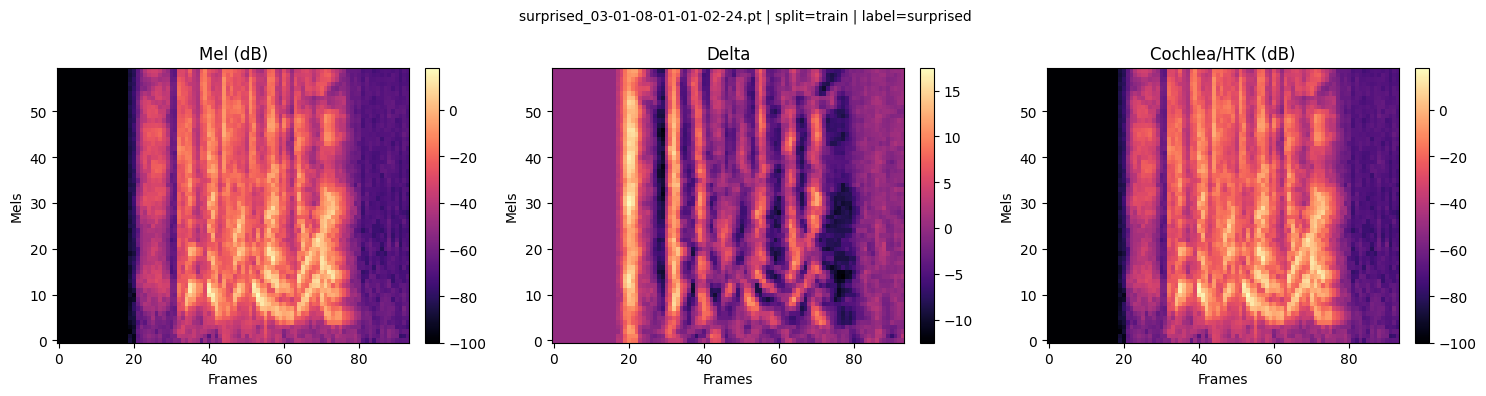

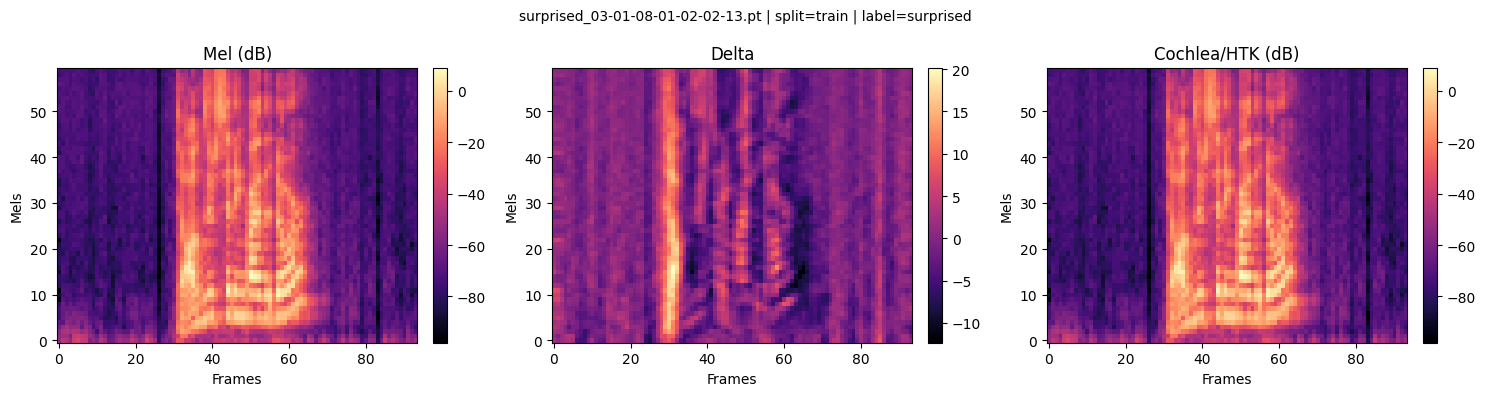

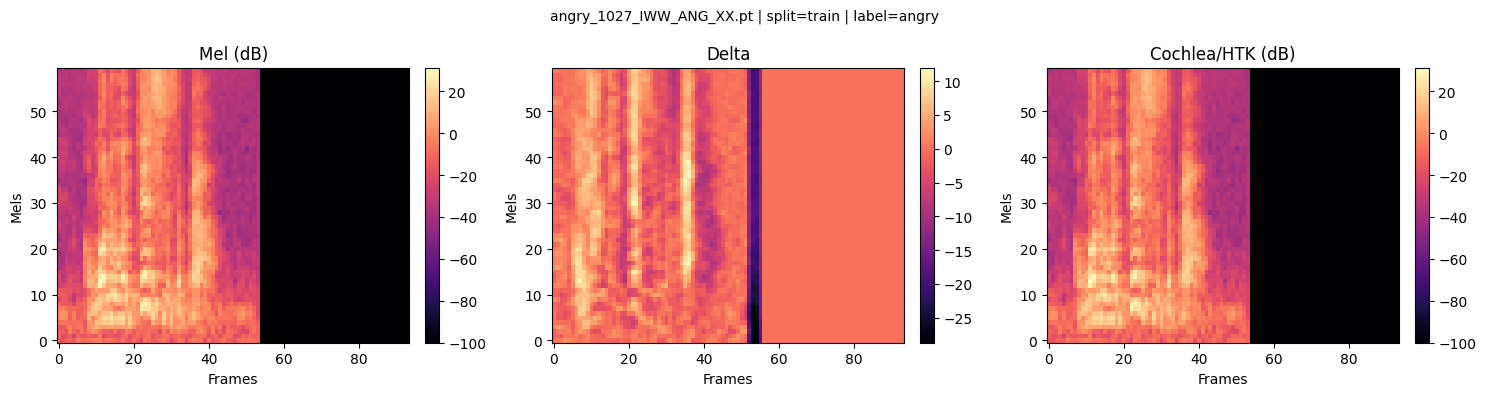

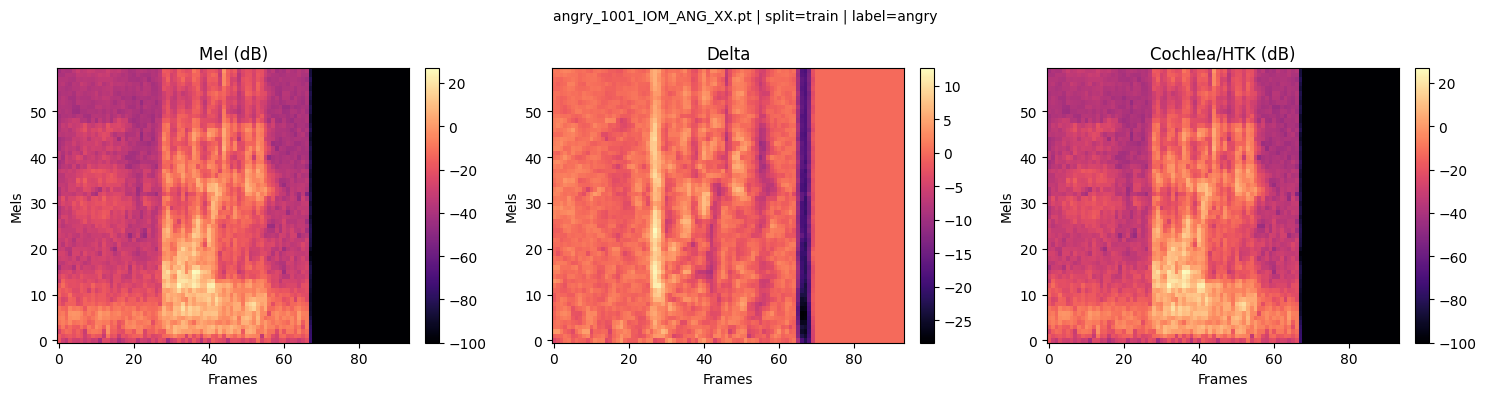

In [48]:
# ============================================================
# Visualización de tensores [3, n_mels, frames]
# Canal 0: Mel, Canal 1: Delta, Canal 2: Cochlea(htk-mel)
# ============================================================
def plot_random_spectrograms(df, split="train", label=None, n=3, seed=123):
    sub = df[df["split"] == split].copy()
    if label is not None:
        sub = sub[sub["label"] == label]

    if len(sub) == 0:
        print(f"No hay muestras para split={split}, label={label}")
        return

    rng = random.Random(seed)
    idxs = rng.sample(list(sub.index), k=min(n, len(sub)))

    for idx in idxs:
        row = sub.loc[idx]
        x = torch.load(row["path"], map_location="cpu")  # [3, n_mels, frames]

        fig, axes = plt.subplots(1, 3, figsize=(15, 4))
        channel_names = ["Mel (dB)", "Delta", "Cochlea/HTK (dB)"]

        for c in range(3):
            im = axes[c].imshow(x[c].numpy(), origin="lower", aspect="auto", cmap="magma")
            axes[c].set_title(channel_names[c])
            axes[c].set_xlabel("Frames")
            axes[c].set_ylabel("Mels")
            plt.colorbar(im, ax=axes[c], fraction=0.046, pad=0.04)

        fig.suptitle(f"{row['filename']} | split={row['split']} | label={row['label']}", fontsize=10)
        plt.tight_layout()
        plt.show()

# Ejemplos:
plot_random_spectrograms(df_index, split="train", label="surprised", n=2)
plot_random_spectrograms(df_index, split="train", label="angry", n=2)